This model infers A/B chromatin compartment structure from the first eigenvector (E1) of the Hi-C contact matrix using a Bayesian framework.

Here we implement dependency between bins with a Gaussian Random Walk (GRW) that is then squished through a sigmoid to obtain probabilities for compartment assignment. 

## Goals

To treat the eigenvector as a soft predictor in stead of deterministic assignment of compartments. Hopefully, we will salvage *some* variance and thus be able to obtain uncertainty estimates for compartment assignment.

## Implementation: GRW on Latent Space

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline
import pymc as pm
import arviz as az
from scipy.stats import norm
from pprint import pprint

## Use a custom style for the plots
plt.style.use('smaller.mplstyle')
matplotlib_inline.backend_inline.set_matplotlib_formats('png', dpi=600)
# %config InlineBackend.figure_formats = ['retina']


### Load/show data

Here, we load the Hi-C contact matrix and the first eigenvector (E1) of the contact matrix. The E1 is used as a predictor for compartment assignment.

The eigendecomposition of the Hi-C matrix was performed with the workflow in the main folder (`workflow.py`), using the **Open2C** ecosystem

In [2]:
# Load the data
resolution = 50000

y = pd.Series(pd.read_csv(f"../data/eigs/sperm.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})
df.dropna(inplace=True)

# # TEST DF

# df = df.iloc[:200]
# df

~~The data are stored as pd.Series() objects, merged into a pd.DataFrame() that is not used. Maybe it would save some typing (for plots) to have the bin numbers converted into the genomic position, so that might be implemented in the future.~~ It already is...

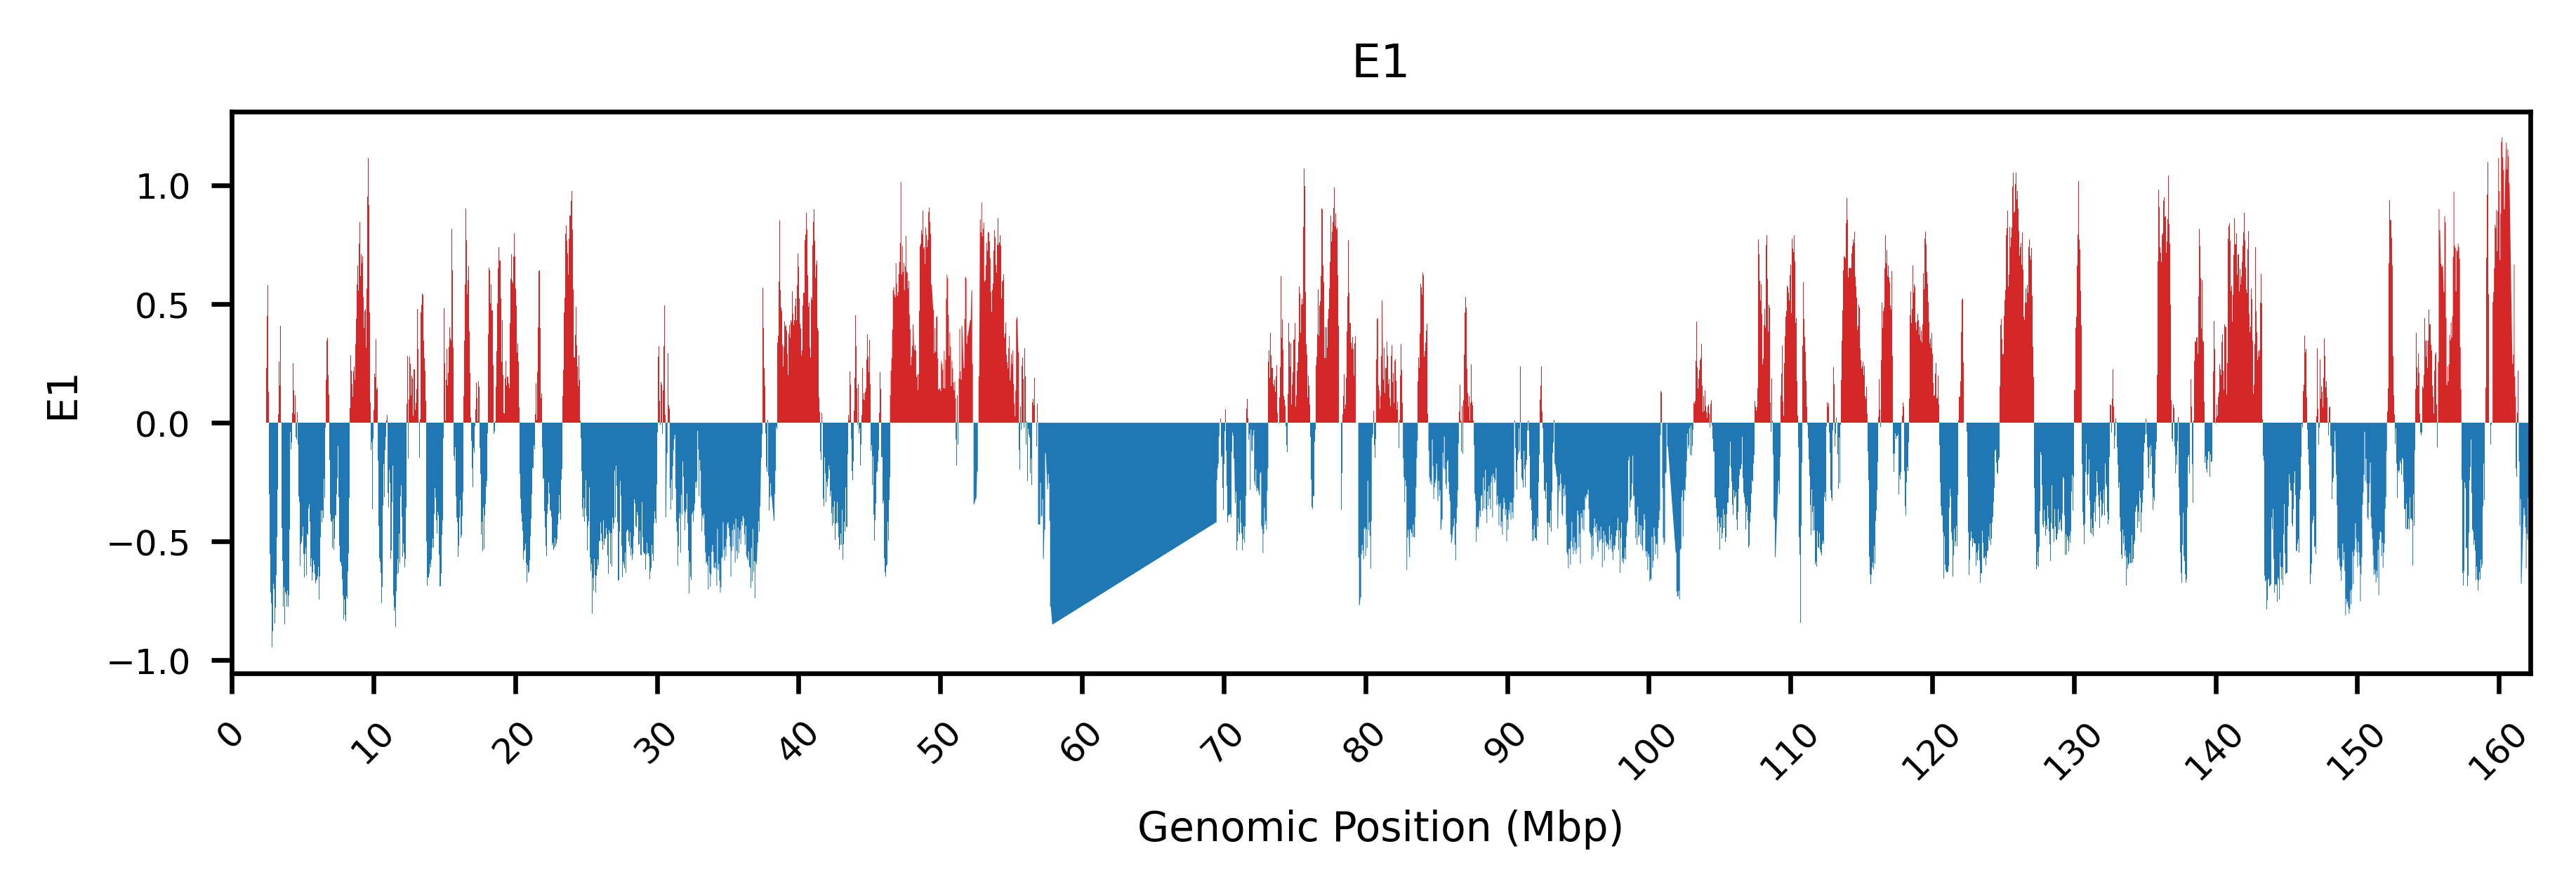

In [3]:
# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots()

x_stair = np.zeros(2*df.start.shape[0])
y_stair = np.zeros(2*df.shape[0])
x_stair[0::2] = df.start
x_stair[1::2] = df.start + resolution
y_stair[0::2] = df.e1
y_stair[1::2] = df.e1


ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", ec='None')

ax.set_xlim(0, df["start"].max()+resolution)
ticks = np.arange(0, df["start"].max()+resolution, step=1e7, dtype=int)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks/1e6).astype(int), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1");

/tmp/ipykernel_2790277/2129628079.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


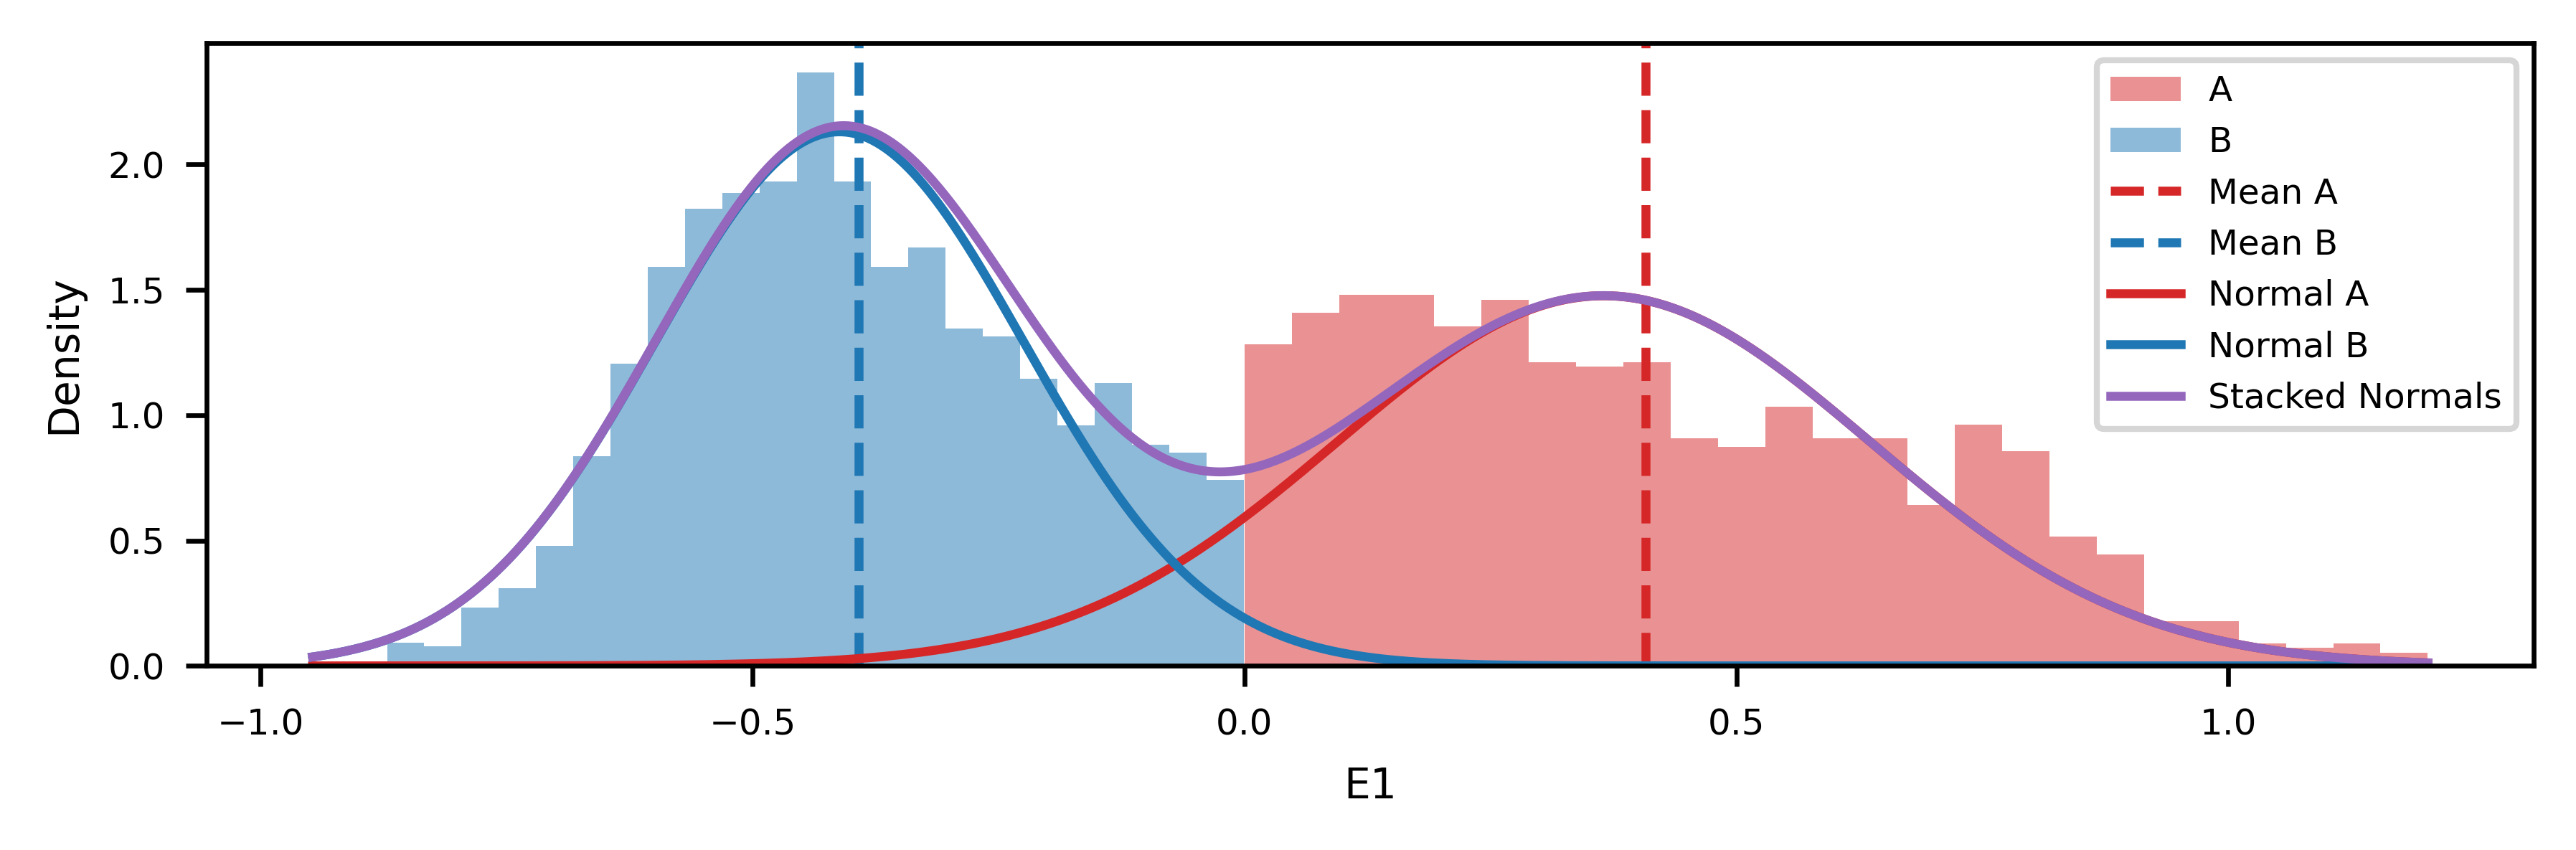

In [4]:
#| echo: false
#| label: "fig-e1-dist-50kb"
#| fig-cap: "Distribution of E1 values across chrX in macaque sperm at 50kb resolution. The theoretical normal distributions with respective means and standard deviations for A (red) and B (blue) compartments are overlaid, along with their combined (stacked) distribution (purple)."
#| fig-scap: "Dist(E1) chrX macaque sperm 50kb"


# Histogram of distribution of E1 values (A and B)

x = df["start"].values
y = df["e1"].values

f, ax = plt.subplots()

# A compartments
ax.hist(y[y>0], bins=25, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=25, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
x_values = np.linspace(y.min(), y.max(), 1000)
mean_a = np.median(y[y>0])
mean_b = np.median(y[y<0])
std_a = y[y>0].std()
std_b = y[y<0].std()

ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

# Final touches
plt.xlabel("E1")
plt.ylabel("Density")
plt.legend(loc='best')
plt.tight_layout()

### Model Specification

Here, the structure of the model is as follows:

We keep the assumption that the E1 values can be drawn from two Gaussian priors, one for A compartments and one for B compartments. To introduce spatial dependency, we use rolling regression with a Gaussian Random Walk (GRW) prior on the latent state variable (`p`) that is then squished through a sigmoid function.  

**NB** We only use a GRW on the latent variable in this model as a simpler alternative GRW on the E1. Guess what comes next.

**Notation** 

Let: 
- $y_i$: Observed E1 value at bin $i$
- $ z_i \in \{0, 1\} $: Latent compartment assignment (0 = B, 1 = A)
- $ \mu_A, \mu_B $: Mean E1 values for compartments A and B
- $ \sigma $: Shared standard deviation across bins
- $ p $: Prior probability of a bin belonging to compartment A

**Model Variables**

$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \text{HalfNormal}(1) \\
logit(p) &\sim \text{GaussianRandomWalk}(\sigma) \\
p_i &\sim \text{Sigmoid}(logit(p)) \\
z_i &\sim \text{Bernoulli}(p_i) \\
\mu_i &= z_i \cdot \mu_A + (1 - z_i) \cdot \mu_B \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
$$

### PyMC

### Visualize distributions

In [5]:

#params = [(0.5, 0.5), (2, 2), (1, 1)]
nus = [3, 5, 10, 20]
mus = [-0.5, 0.5]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]

fig, axs = plt.subplots((len(nus)), figsize=(10, 4*len(nus)))
axs = axs.flatten()

for nu,col,ax in zip(nus, colors, axs):
    with pm.Model() as yhat_priors:
        nu_T = pm.StudentT("nu_T", nu=nu, mu=mus, sigma=0.3)
        nu_norm = pm.Normal("nu_norm", mu=mus, sigma=0.3)
        prior = pm.sample_prior_predictive(samples=10000)
        ax.set_title("Comparison of priors for yhat")
        az.plot_kde(prior.prior["nu_T"].values, label=f"StudT(nu={nu})", ax=ax, fill_kwargs={"alpha": 0.1, "color":colors[0]})
        ax.set_title("Comparison of priors for yhat")
        az.plot_kde(prior.prior["nu_norm"].values, label="Normal", ax=ax, fill_kwargs={"alpha": 0.1, "color":colors[1]})
        ax.set_xlim(-2, 2)
        plt.tight_layout()

Sampling: [nu_T, nu_norm]
/tmp/ipykernel_2790277/4030595694.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
Sampling: [nu_T, nu_norm]
Sampling: [nu_T, nu_norm]
Sampling: [nu_T, nu_norm]


##### Legacy: Centered GRW 

In [6]:
with pm.Model(coords={"pos": df.index.values}) as legacy_model:
    """
    Model E1 track as a continous mixture of two normals using a Gaussian Random Walk (GRW) to model the mixing proportions.
    The GRW is applied to the logit space to ensure the mixing proportions are between 0 and 1.
    """
    e1 = pm.Data("e1", df.e1.values, dims="pos")
    n = e1.shape[0]

    mu_a = pm.Normal("mu_a", 0.5, 0.3)
    mu_b = pm.Normal("mu_b", -0.5, 0.3)
    sigma = pm.HalfNormal("sigma", 0.3)

    # GRW over logit space
    grw_sigma = pm.HalfNormal("grw_sigma", 0.1)
    logit_w = pm.GaussianRandomWalk("logit_w", 
                                    sigma=grw_sigma, shape=n, 
                                    init_dist=pm.Normal.dist(mu=0.0, sigma=1.0),  # or a tighter prior if preferred
                                    dims="pos"
                                    )
    w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

    components = pm.Normal.dist(mu = pm.math.stack([mu_a, mu_b]),
                           sigma = sigma, 
                           shape=(2,))

    # Likelihood estimate
    y_hat = pm.Mixture("y_hat", w=pm.math.stack([w,1-w], axis=1), comp_dists=components, observed=e1, dims='pos')


##### New: Non-centered GRW

This patch is **still a Gaussian Random Walk**, but expressed in a **non-centered form**.

##### What stays the same:

- The process is still a **cumulative sum of Gaussian increments**, i.e.,  
  $$\text{logit}_w[t] = \sum_{i=1}^t \epsilon_i \cdot \sigma$$  
  where $\epsilon_i \sim \mathcal{N}(0,1)$.  
  This is exactly what a GRW is.

##### What's different:

- Instead of sampling $\text{logit}_w$ directly, we sample the **standardized increments** $\epsilon$ and reconstruct $\text{logit}_w$ via `cumsum`.
- This reduces posterior curvature and pathologies, especially around $\sigma$, improving NUTS performance.

##### Why it helps:

- In the centered form, large values of `grw_sigma` lead to very spread-out walks → hard geometry.
- The non-centered form handles the scale explicitly, so NUTS explores $\epsilon$ space more efficiently.


In [7]:
import pytensor.tensor as pt

with pm.Model(coords={"pos": df.index.values}) as model:
    """
    Model E1 track as a continous mixture of two normals using a Gaussian Random Walk (GRW) to model the mixing proportions.
    The GRW is applied to the logit space to ensure the mixing proportions are between 0 and 1.
    This is a non-centered reparameterization of the model.
    The model uses ordered parameters for mu_a and mu_b to ensure they are distinct and do not switch.
    """
    e1 = pm.Data("e1", df.e1.values, dims="pos")

    # Old version, not ordered
    # mu_a = pm.Normal("mu_a", 0.5, 0.3)
    # mu_b = pm.Normal("mu_b", -0.5, 0.3)
    # New: Make ordered parameters for mu_a and mu_b in stead
    mu = pm.Normal("mu", mu=[-0.5, 0.5], sigma=0.3,
        transform=pm.distributions.transforms.ordered, # IMPORTANT
        shape=2,
        )
    sigma = pm.HalfNormal("sigma", 0.3, shape=2)

    # GRW over logit space; non-centered reparameterization
    grw_sigma = pm.HalfNormal("grw_sigma", 0.05)
    # Normal distribution for eps
    #eps = pm.Normal("eps", mu=0.0, sigma=1, dims="pos")

    # StudentT distribution for eps (got alot of divergences with nu=3)
    eps = pm.StudentT("eps", nu=10, mu=0.0, sigma=1.0, dims="pos")
    
    logit_w = pm.Deterministic("logit_w", pt.cumsum(eps * grw_sigma), dims="pos")
    w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

    # Old version, not ordered
    # components = pm.Normal.dist(mu = pm.math.stack([mu_a, mu_b]), sigma = sigma, shape=(2,))
    
    # New: Use the ordered mu parameters (cleaner code as well)
    # components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)
    components = pm.StudentT.dist(nu=10, mu=mu, sigma=sigma, shape=2)

    # Likelihood estimate
    y_hat = pm.Mixture("y_hat", w=pm.math.stack([w,1-w], axis=1), comp_dists=components, observed=e1, dims='pos')


#### Model graphs

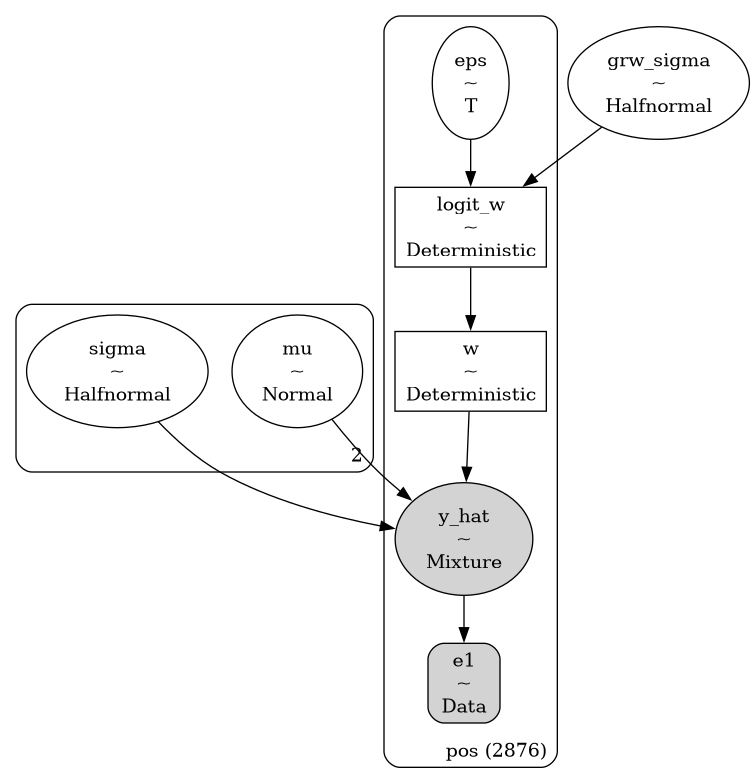

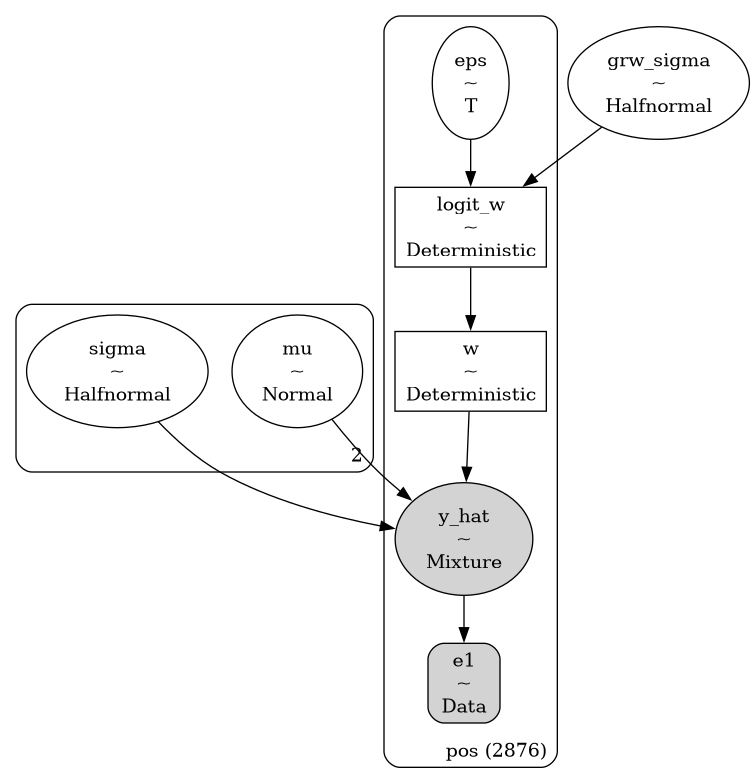

In [9]:
# Visualize
# display(legacy_model.to_graphviz(),
#         model.to_graphviz())

from IPython.display import Image

gv1 = pm.model_to_graphviz(legacy_model, figsize=(5,5)).render(format='png')
gv2 = pm.model_to_graphviz(model, figsize=(5,5)).render(format='png')

display(Image(gv1))
display(Image(gv2))


In [9]:
with model:
    # Sample from the prior
    idata = pm.sample_prior_predictive(samples=1000)

idata

Sampling: [eps, grw_sigma, mu, sigma, y_hat]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [10]:
prior_predictive_e1 = az.extract(idata, group="prior_predictive", var_names=["y_hat"])

print(pd.DataFrame({
    "Statistic": ["Min", "Max", "Std"],
    "Value": [
        prior_predictive_e1.values.min(),
        prior_predictive_e1.values.max(),
        prior_predictive_e1.values.std()
    ]
}))

#y_lik_norm (min, max, std): {prior_predictive_e1.y_lik_norm.values.min(), prior_predictive_e1.y_lik_norm.values.max(), prior_predictive_e1.y_lik_norm.values.std()}

  Statistic     Value
0       Min -8.414395
1       Max  6.529312
2       Std  0.665646


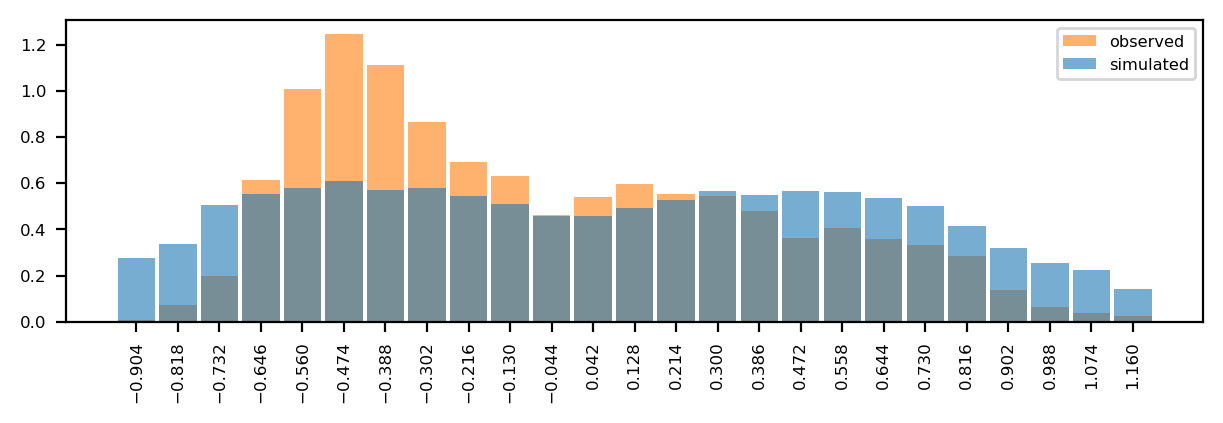

In [11]:
e1_obs = df['e1'].values

az.plot_dist(
    e1_obs,
    kind="hist",
    color="C1", 
    hist_kwargs={"alpha": 0.6,  "bins": 25},
    label="observed"
)



prior_pred_obs = idata.prior_predictive["y_hat"].stack(sample=("chain", "draw")).values
prior_pred_obs = prior_pred_obs[prior_pred_obs > e1_obs.min()]  # Constrain the range to observed values
prior_pred_obs = prior_pred_obs[prior_pred_obs < e1_obs.max()]  # Constrain the range to observed values

az.plot_dist(
    prior_pred_obs,
    kind="hist",
    hist_kwargs={"alpha": 0.6, "bins":25},
    label="simulated",
)
plt.xticks(rotation=90);



#### Posterior sampling


In [12]:
with model:
    # Sample from the posterior
    trace = pm.sample(1000, tune=1000, cores=8, chains=8, target_accept=0.95, progressbar=False)


idata.extend(trace)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (8 chains in 8 jobs)


NUTS: [mu, sigma, grw_sigma, eps]


Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 1235 seconds.


***Outfrom `legacy_model`***

```raw
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [mu_a, mu_b, sigma, grw_sigma, logit_w]

Sampling 8 chains for 2_000 tune and 1_000 draw iterations (16_000 + 8_000 draws total) took 1377 seconds.
There were 106 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 4 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 5 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 6 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 7 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
```

In [13]:
with model:
    # Posterior predictive checks
    ppc = pm.sample_posterior_predictive(idata, var_names=["y_hat"], random_seed=42, extend_inferencedata=True)


Sampling: [y_hat]


Output()

In [14]:
idata


Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

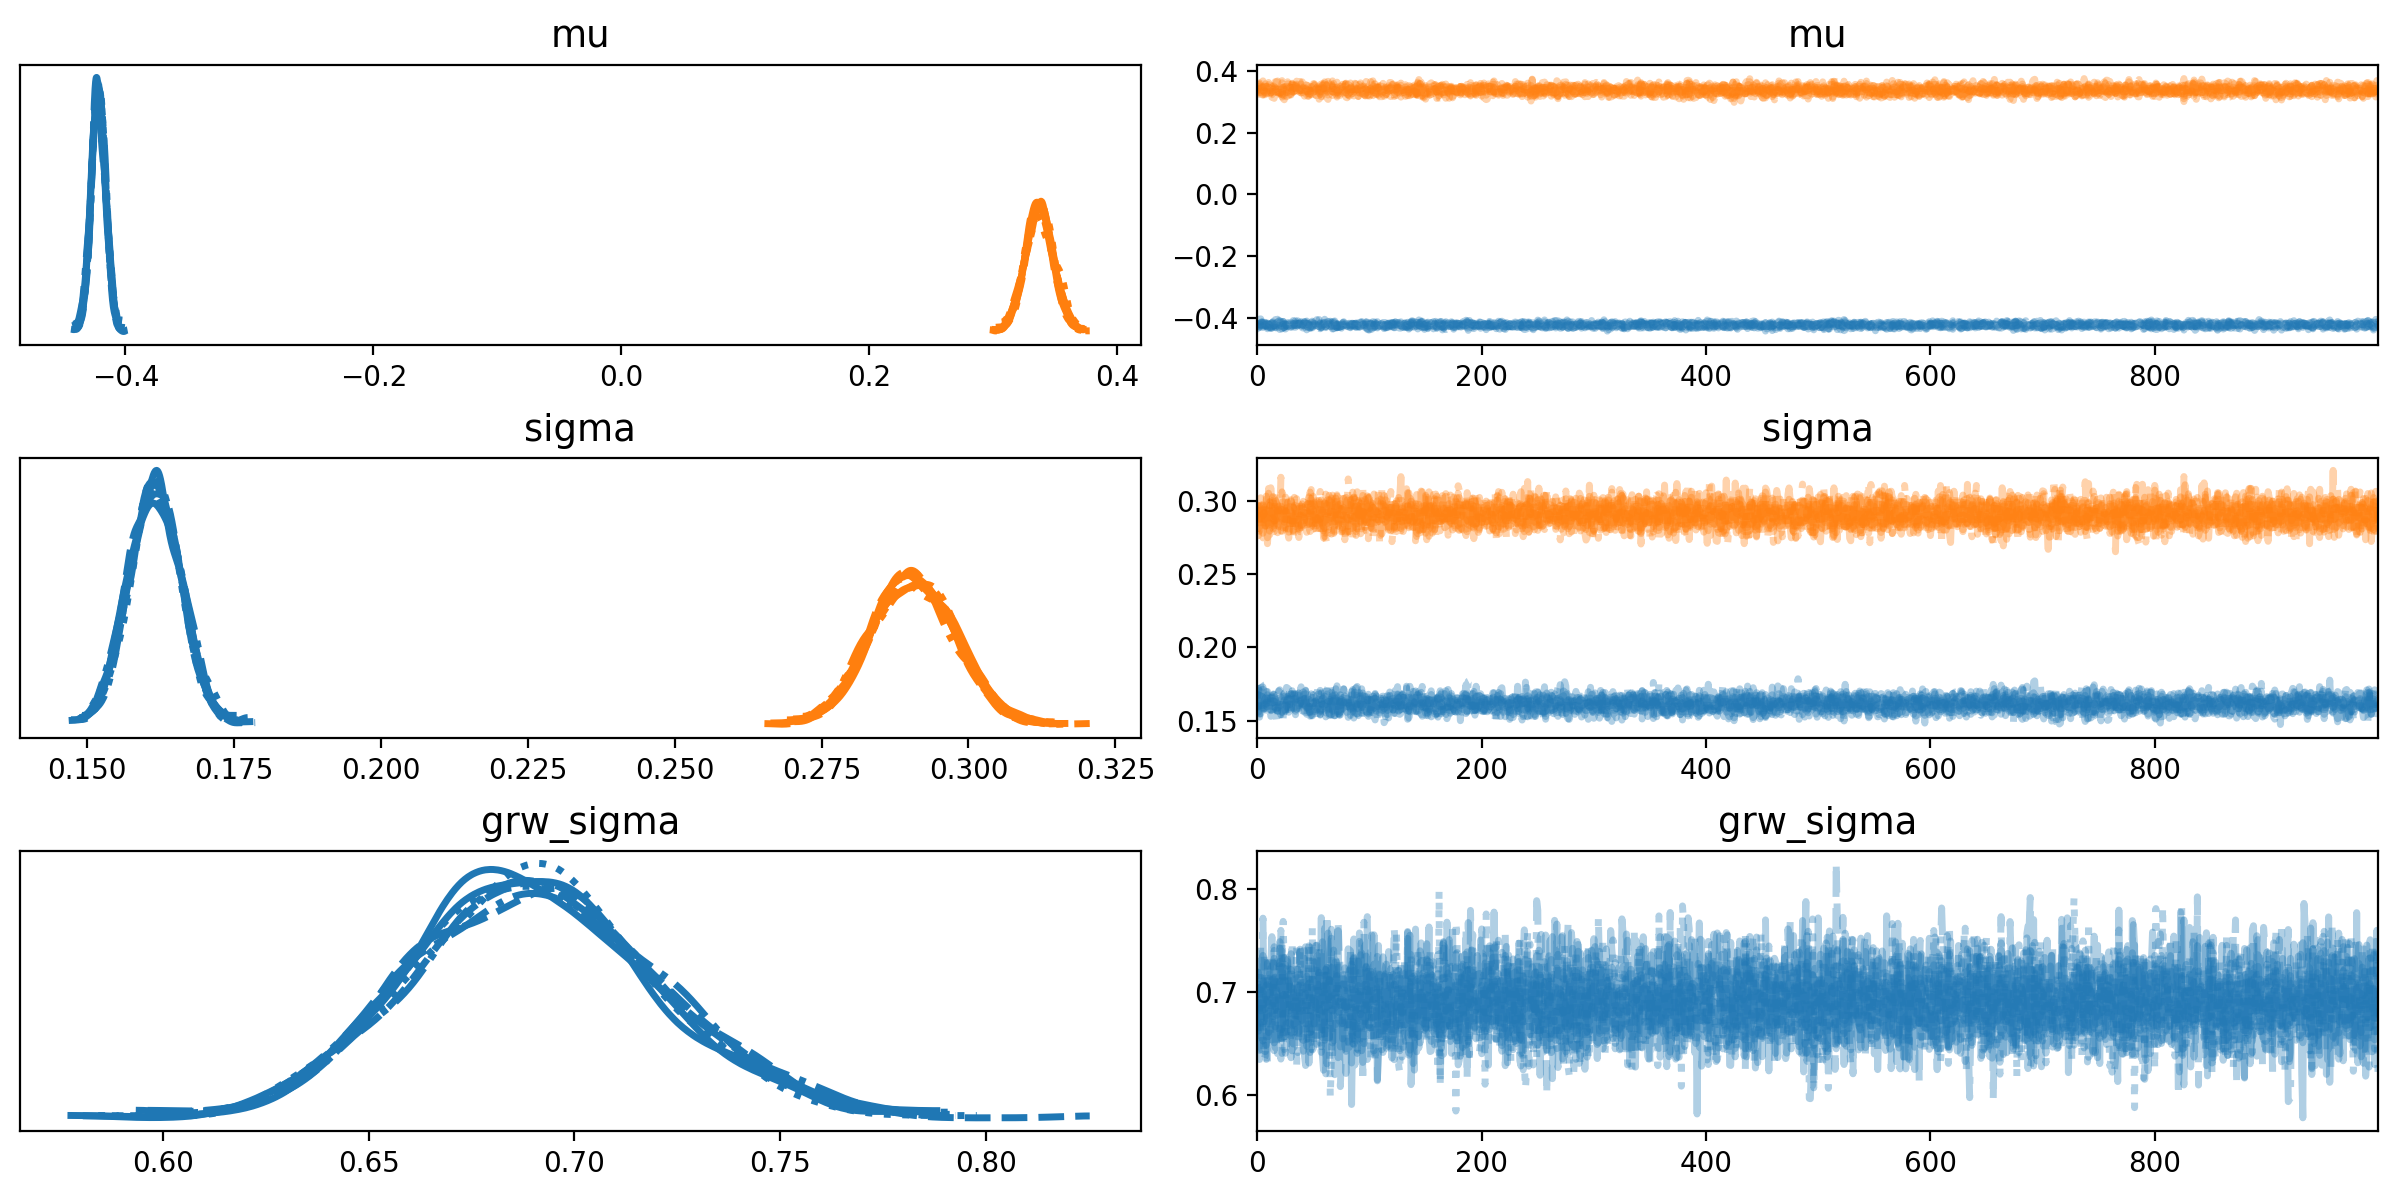

In [15]:
# az.plot_trace(idata, var_names=['mu_a','mu_b', 'grw_sigma'],combined=True, backend_kwargs={'layout': 'tight'})
az.plot_trace(idata, var_names=['mu', 'sigma', 'grw_sigma'], compact=True, backend_kwargs={'layout': 'tight'});

In [16]:
# az.summary(idata, var_names=['mu_a','mu_b', 'grw_sigma'], kind='stats', round_to=2)
az.summary(idata, var_names=['mu', 'sigma', 'grw_sigma'], kind='stats', round_to=2)


,mean,sd,hdi_3%,hdi_97%
mu[0],-0.42,0.01,-0.43,-0.41
mu[1],0.34,0.01,0.32,0.36
sigma[0],0.16,0.00,0.15,0.17
sigma[1],0.29,0.01,0.28,0.30
grw_sigma,0.69,0.03,0.63,0.75


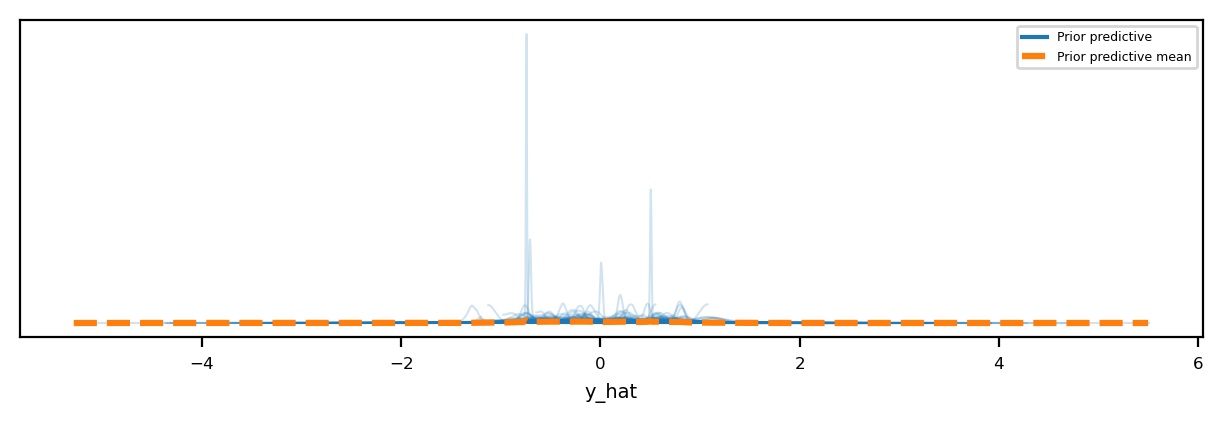

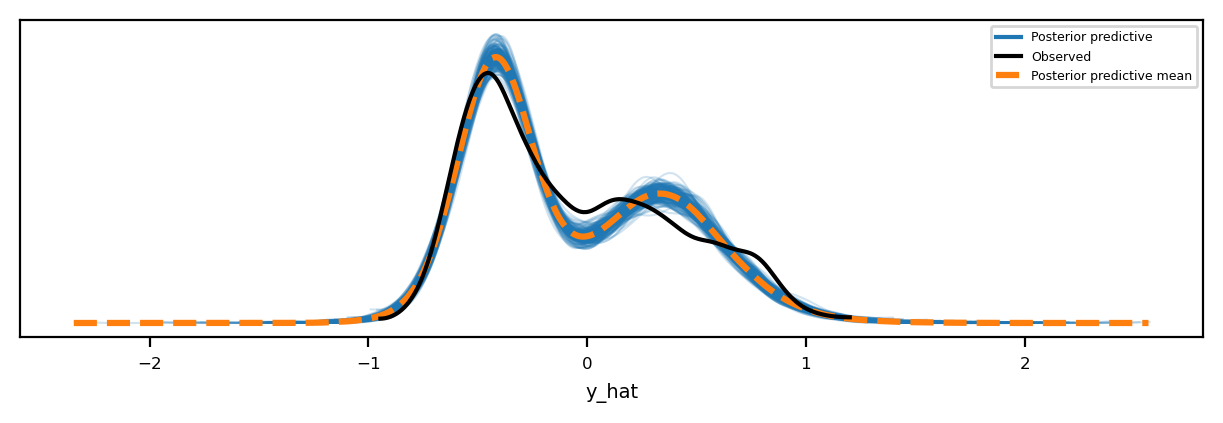

In [17]:
az.plot_ppc(idata, var_names=["y_hat"], num_pp_samples=200, group='prior');
az.plot_ppc(idata, var_names=["y_hat"], num_pp_samples=200);

In [18]:
with model:
    ll = pm.compute_log_likelihood(idata, var_names=["y_hat"])

Output()

In [19]:
az.loo(idata)

/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 2876 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -137.23    36.72
p_loo       84.89        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2872   99.9%
   (0.70, 1]   (bad)         4    0.1%
   (1, Inf)   (very bad)    0    0.0%

<Axes: xlabel='y_hat'>

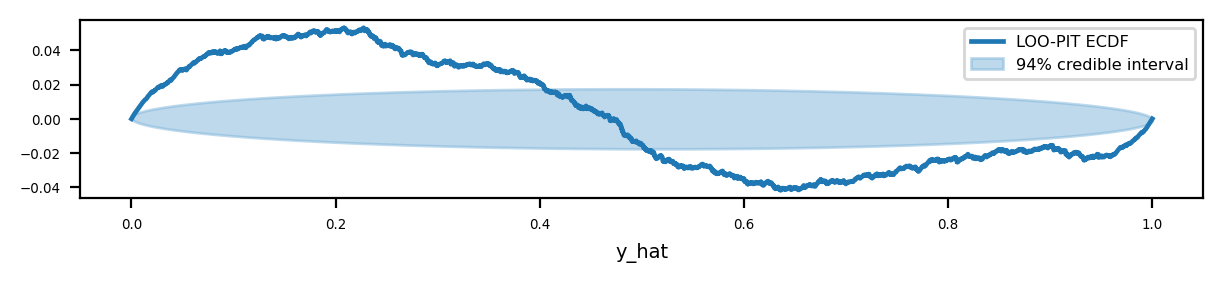

In [20]:
#| echo: false
#| label: "fig-grw-ppc-50kb-loo-pit"
#| fig-cap: "LOO-PIT plot, transformed to ECDF/CDF for the observed/uniform distributions respectively, for the E1 model on macaque sperm at 50kb resolution. ECDF outside the credible interval indicates misfit."
#| fig-scap: "LOO-PIT E1 model chrX macaque sperm 50kb"


az.plot_loo_pit(idata, y = "y_hat", ecdf=True, figsize=(6,1.3))
# plt.tight_layout()

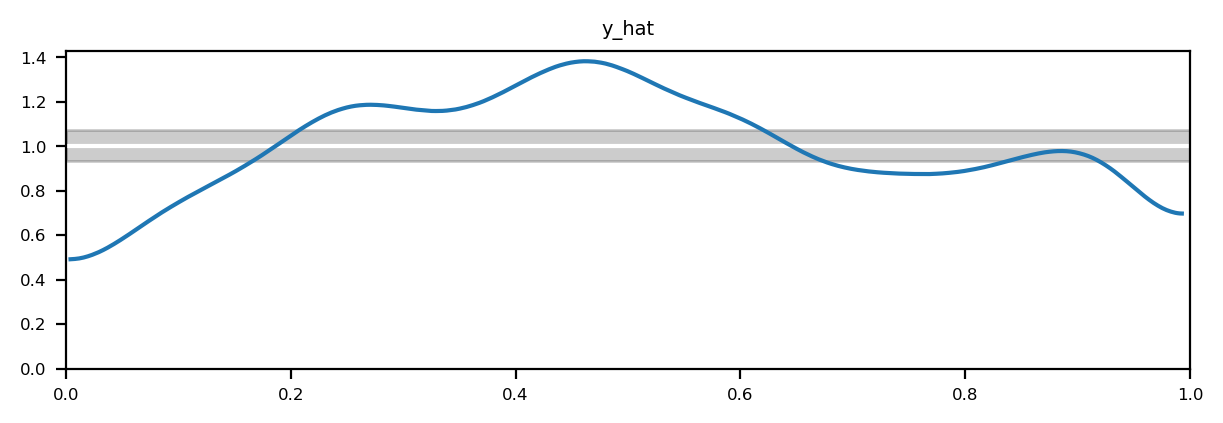

In [21]:
az.plot_bpv(idata);

In [22]:
trace_yhat = az.summary(idata, var_names=["y_hat"], kind="stats", group="posterior_predictive")
trace_yhat

,mean,sd,hdi_3%,hdi_97%
y_hat[48],0.017,0.467,-0.713,0.832
y_hat[49],0.028,0.465,-0.752,0.780
y_hat[50],-0.005,0.466,-0.729,0.805
y_hat[51],-0.062,0.458,-0.724,0.788
y_hat[52],-0.169,0.434,-0.798,0.688
...,...,...,...,...
y_hat[3239],-0.327,0.323,-0.833,0.435
y_hat[3240],-0.310,0.337,-0.803,0.492
y_hat[3241],-0.286,0.361,-0.779,0.568
y_hat[3242],-0.241,0.397,-0.774,0.624


         mean      sd
means -0.0727  0.3212
sds    0.3149  0.0846


/tmp/4104825/ipykernel_684246/3664953425.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


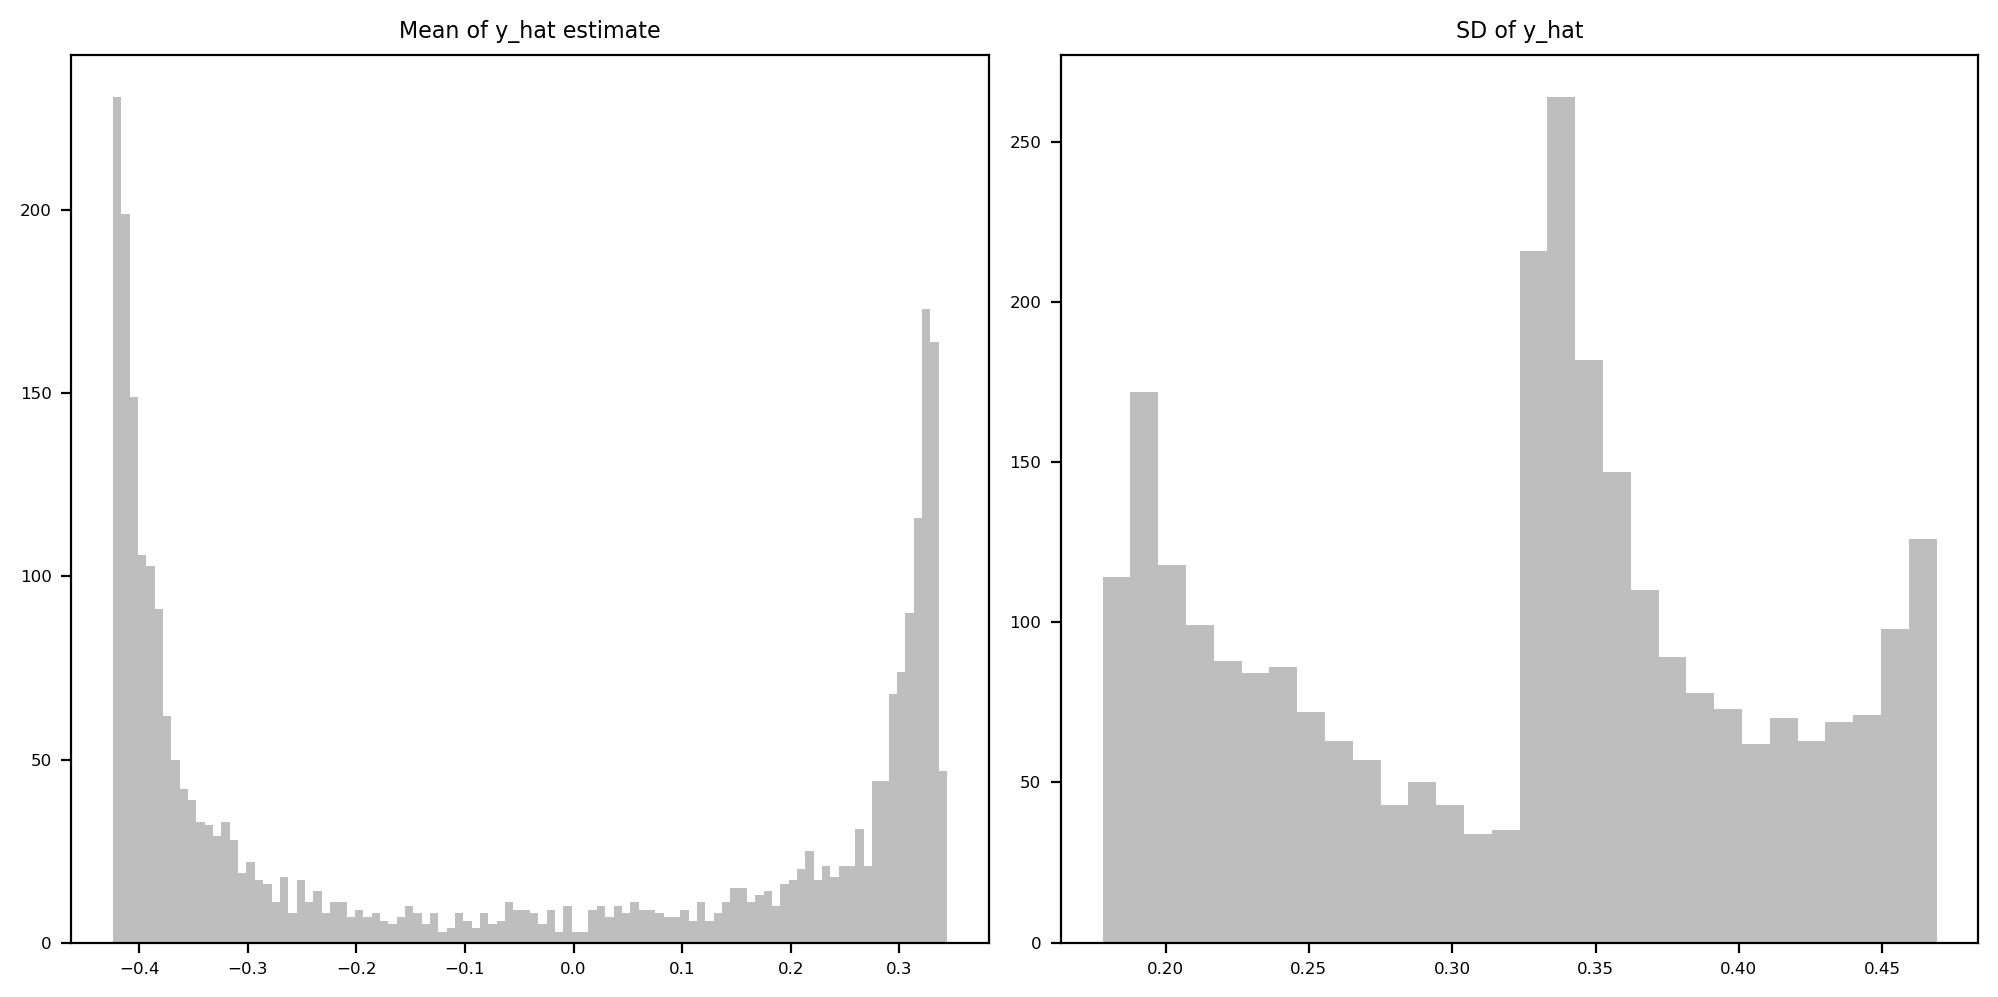

In [23]:
print(pd.DataFrame({
    "mean": [trace_yhat['mean'].mean(), trace_yhat['mean'].std()],
    "sd": [trace_yhat['sd'].mean(), trace_yhat['sd'].std()]
}).set_index(pd.Index(['means', 'sds'])).round(4))

f,ax = plt.subplots(1,2, figsize=(10, 5))
ax = ax.flatten()
ax[0].set_title("Mean of y_hat estimate")
ax[0].hist(trace_yhat['mean'], bins=100, color="tab:grey", alpha=0.5)
#ax[0].set_xlim(-0.05,0.05) # zoom-in on the near-zero peak
ax[1].set_title("SD of y_hat")
ax[1].hist(trace_yhat['sd'], bins=30, color="tab:grey", alpha=0.5)
plt.tight_layout()

/tmp/4104825/ipykernel_684246/1713471822.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


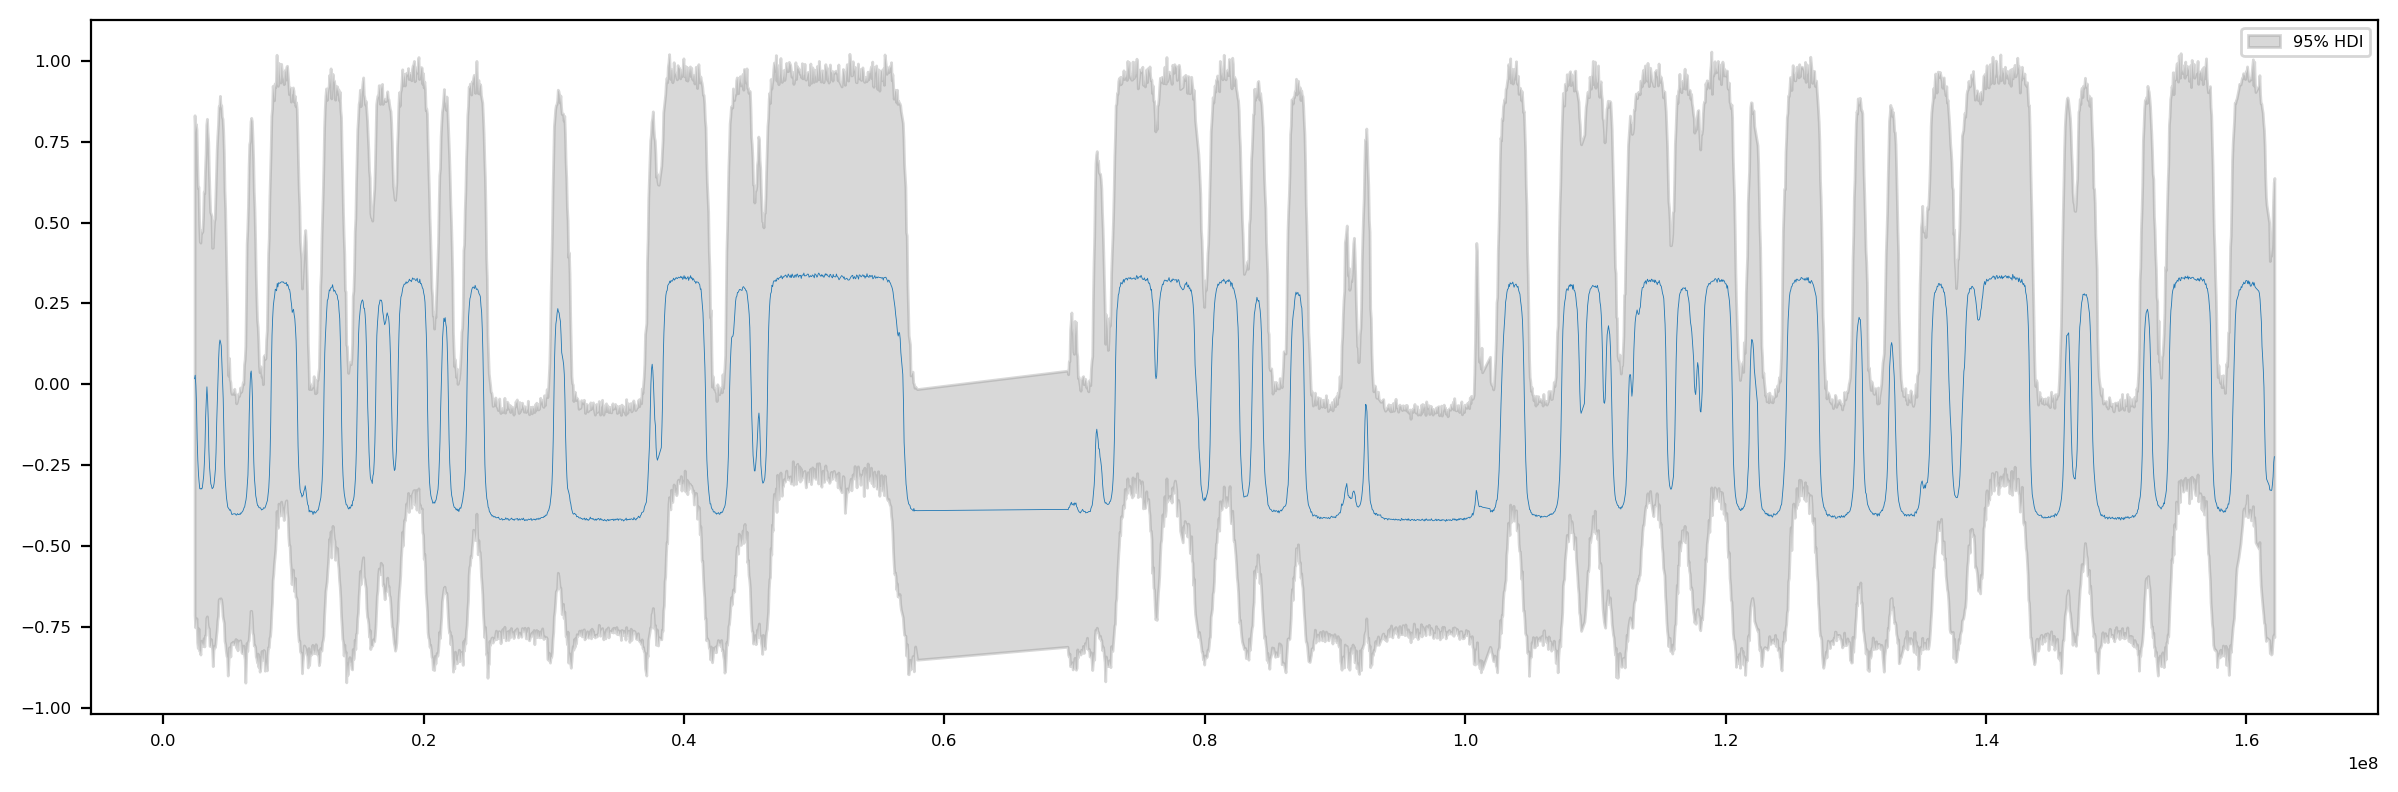

In [24]:
f,ax = plt.subplots(figsize=(12,4))
ax.plot(df['start'], trace_yhat['mean'], lw=0.3)
ax.fill_between(df['start'], trace_yhat['hdi_97%'], trace_yhat['hdi_3%'], color="tab:grey", alpha=0.3, label="95% HDI")
plt.legend()
plt.tight_layout()


In [25]:
idata.posterior_predictive.stack(sample=("chain", "draw"))

<xarray.Dataset> Size: 184MB
Dimensions:  (pos: 2876, sample: 8000)
Coordinates:
  * pos      (pos) int64 23kB 48 49 50 51 52 53 ... 3239 3240 3241 3242 3243
  * sample   (sample) object 64kB MultiIndex
  * chain    (sample) int64 64kB 0 0 0 0 0 0 0 0 0 0 0 ... 7 7 7 7 7 7 7 7 7 7 7
  * draw     (sample) int64 64kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y_hat    (pos, sample) float64 184MB 0.09195 0.2116 ... 0.2393 -0.3362
Attributes:
    created_at:                 2025-09-03T13:26:09.231230+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.25.1

In [26]:
y_ppc = idata.posterior_predictive["y_hat"]

y_ppc_flat = y_ppc.stack(sample=("chain", "draw"))


ppc_mean = y_ppc_flat.mean(dim="sample").values       # mean of predictions per bin
ppc_std = y_ppc_flat.std(dim="sample").values         # predictive std (uncertainty)
ppc_hdi = az.hdi(y_ppc, hdi_prob=0.95)   

/tmp/4104825/ipykernel_684246/1300968508.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


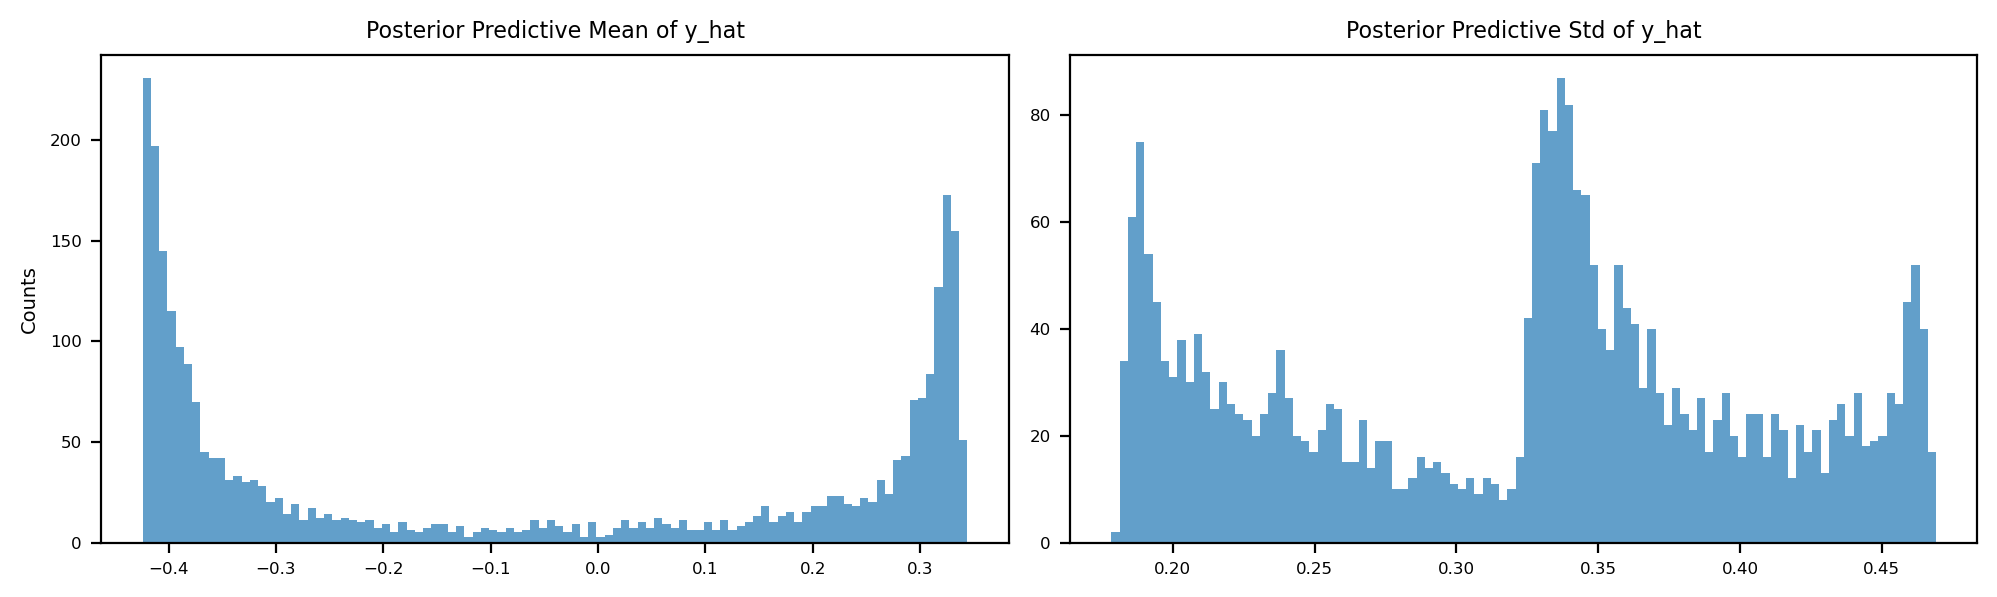

In [27]:
f,ax= plt.subplots(1,2, figsize=(10, 3))
ax[0].set_title("Posterior Predictive Mean of y_hat")
ax[0].set_ylabel("Counts")
ax[0].hist(ppc_mean, bins=100, alpha=0.7, label="Mean(y_hat)")
ax[1].set_title("Posterior Predictive Std of y_hat")
ax[1].hist(ppc_std, bins=100, alpha=0.7, label="Std(y_hat)")
plt.tight_layout()


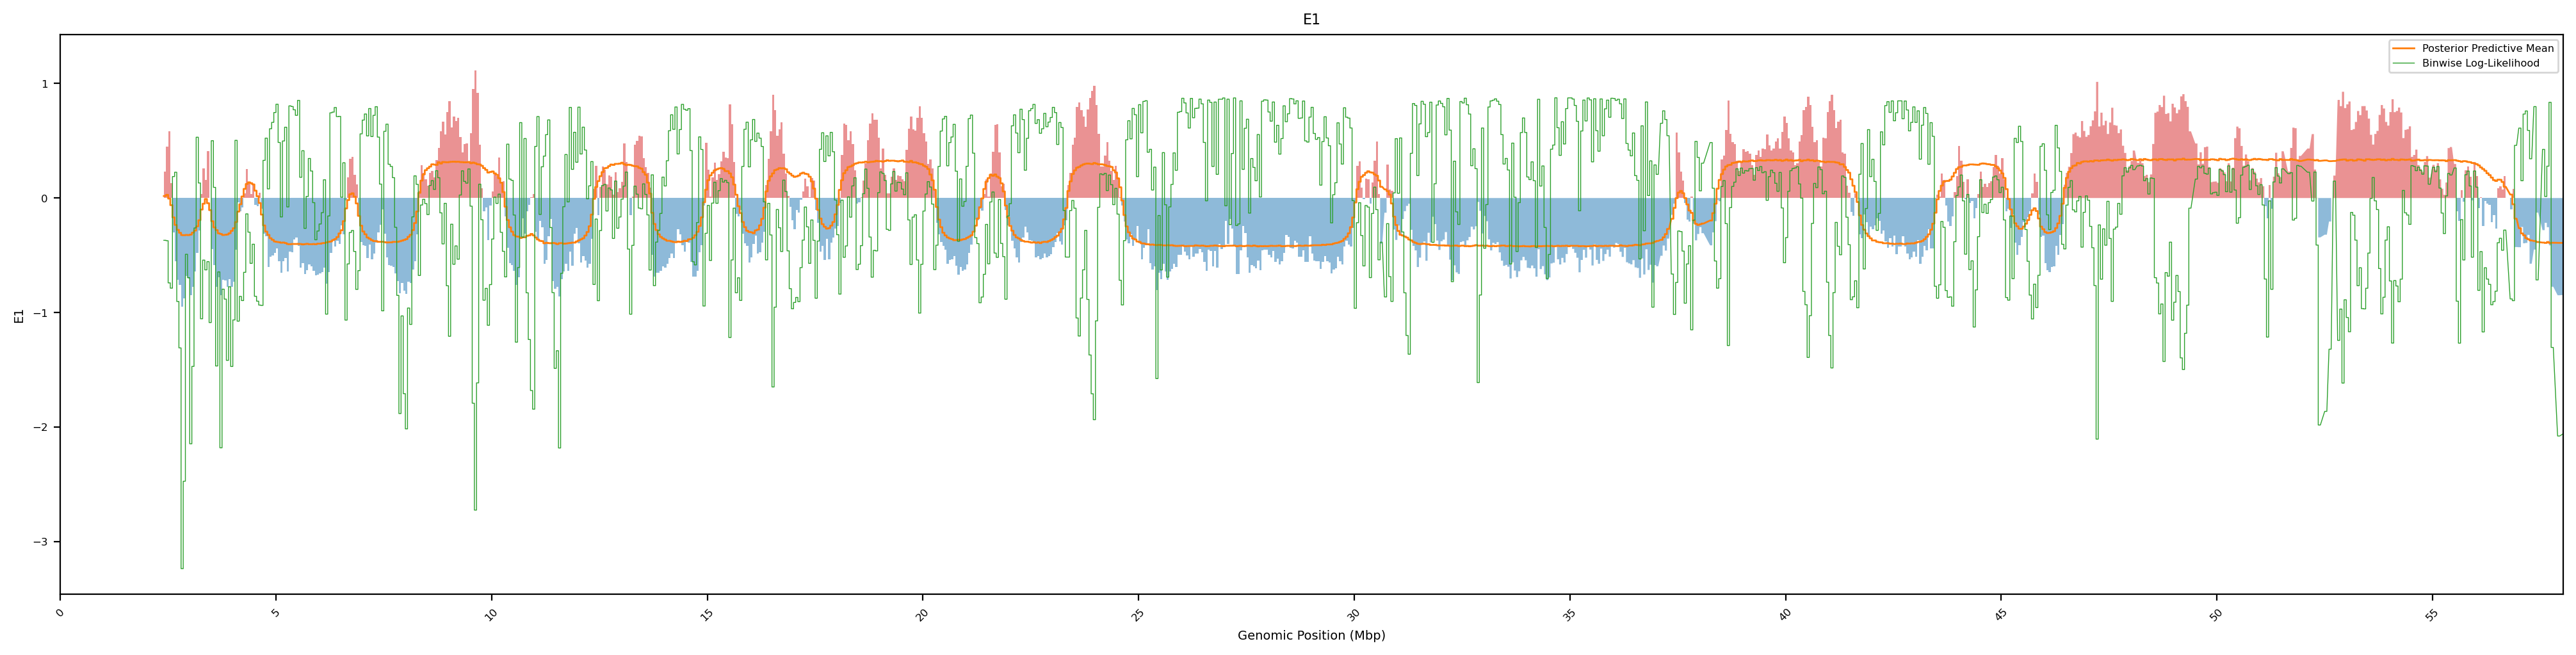

In [28]:
# ppc_mean: shape (bins,)
# mean_ll: shape (bins,)

posterior_mean = idata.posterior_predictive["y_hat"].mean(dim=["chain", "draw"]).values
mean_ll = idata.log_likelihood.y_hat.mean(dim=["chain", "draw"]).values
x = df.start.values
y = df.e1.values

# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots(figsize=(20, 5))

# Stairs
x_stair = np.zeros(2*y.shape[0])
y_stair = np.zeros(2*y.shape[0])
x_stair[0::2] = x
x_stair[1::2] = x + resolution
y_stair[0::2] = y
y_stair[1::2] = y

ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", alpha=0.5, ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", alpha=0.5, ec='None')

# plot the y_ppc_flat mean
post_mean_stairs = np.zeros(2*y.shape[0])
post_mean_stairs[0::2] = posterior_mean
post_mean_stairs[1::2] = posterior_mean
ax.plot(x_stair, post_mean_stairs, lw=1, label="Posterior Predictive Mean", color="tab:orange")

# Plot the point-wise log-likelihood
ll_stair = np.zeros(2*mean_ll.shape[0])
ll_stair[0::2] = mean_ll
ll_stair[1::2] = mean_ll
ax.plot(x_stair, ll_stair, lw=0.5, label="Binwise Log-Likelihood", color="tab:green")

ax.set_xlim(0, 57_984_683 + resolution)
ticks = np.arange(0, 57_984_683, step=5_000_000)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks / 1e6).astype(int), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1")
ax.legend(loc="best");

/tmp/4104825/ipykernel_684246/662262831.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


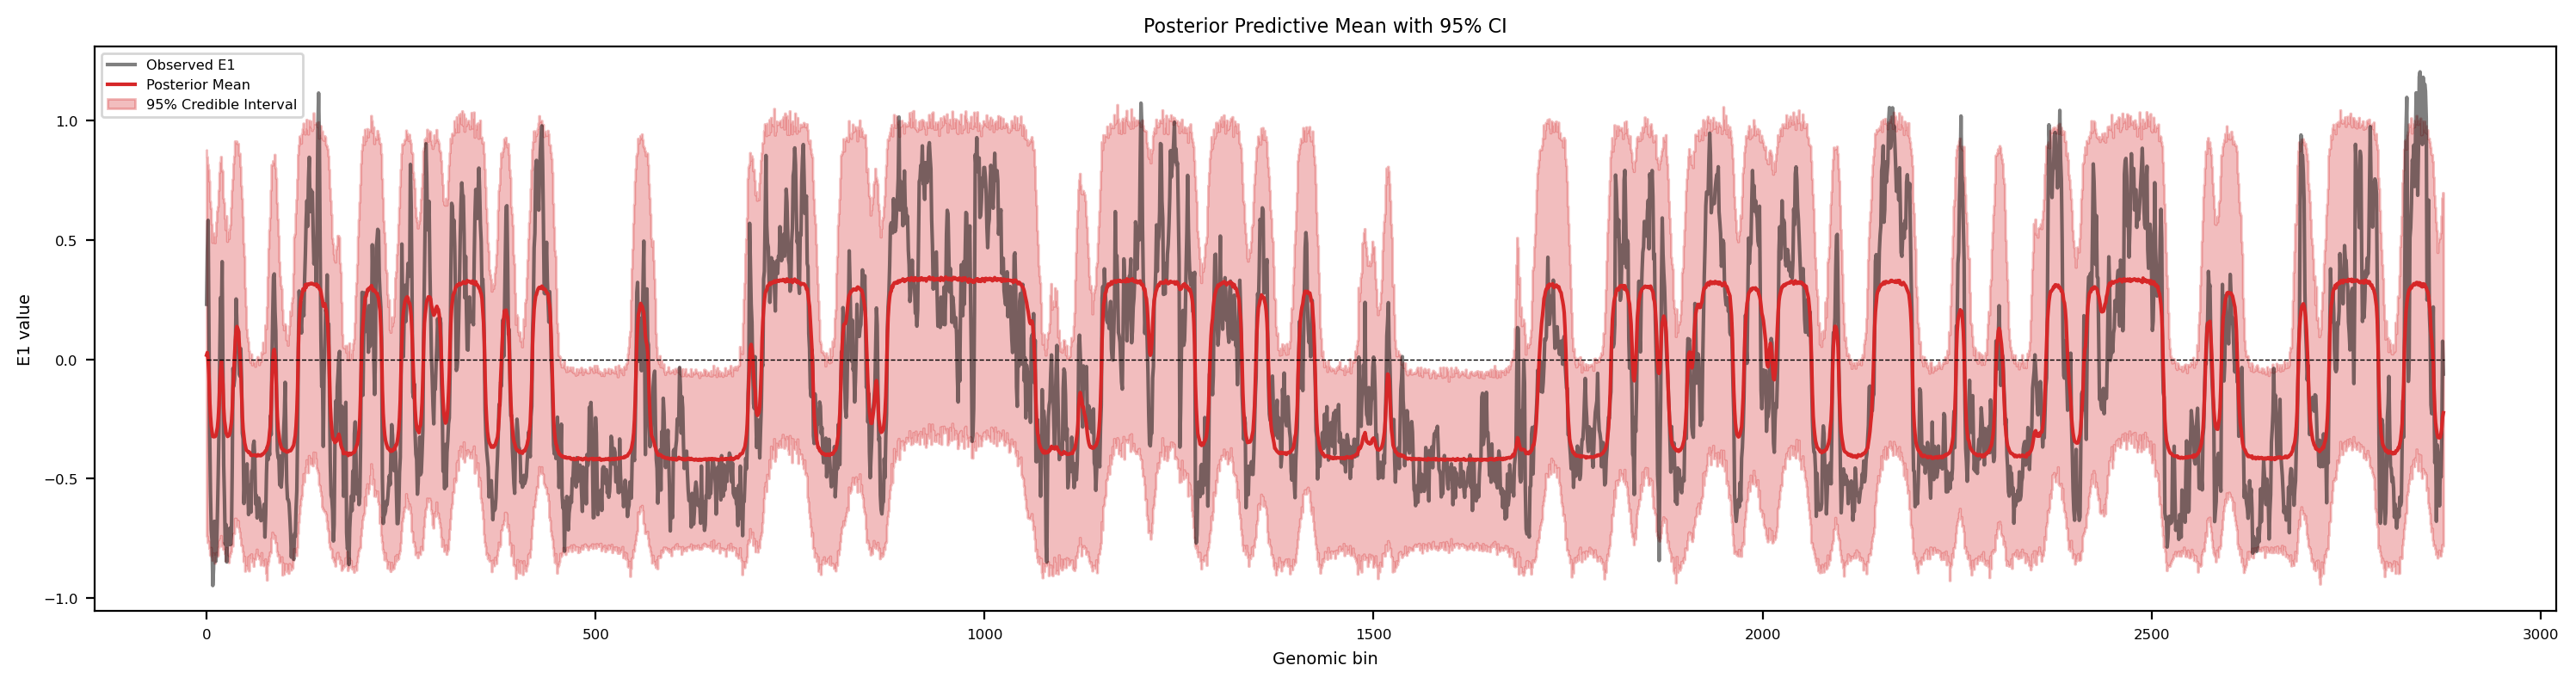

In [29]:
bins = np.arange(len(y))

plt.figure(figsize=(15, 4))

# Observed data
plt.plot(bins, y, label="Observed E1", color="black", alpha=0.5)

# Posterior predictive mean
plt.plot(bins, ppc_mean, label="Posterior Mean", color="tab:red")

# Credible interval shading
plt.fill_between(
    bins,
    ppc_hdi.y_hat.sel(hdi='lower').values,
    ppc_hdi.y_hat.sel(hdi='higher').values,
    color="tab:red",
    alpha=0.3,
    label="95% Credible Interval",
    step='pre'
)

plt.hlines(0, xmin=0, xmax=bins.shape[0], color='black', linestyle='--', linewidth=0.5)

plt.xlabel("Genomic bin")
plt.ylabel("E1 value")
plt.title("Posterior Predictive Mean with 95% CI")
plt.legend()
plt.tight_layout()
plt.show()
